Loading Libraries & 10x Data into Scanpy

In [2]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from pathlib import Path
import seaborn as sns

# Configure Scanpy plotting settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=120, facecolor="white", frameon=False)


**Load the core comparative cohort into a unified AnnData object:**

In [15]:
from pathlib import Path
print(Path.cwd())

import os
os.chdir(r"D:\bmp\scRNAseq\sc-project-data\project4_immune_remodeling_cc")

print(os.getcwd())

D:\bmp\scRNAseq\sc-project-data\project4_immune_remodeling_cc
D:\bmp\scRNAseq\sc-project-data\project4_immune_remodeling_cc


In [7]:
data_dir = Path("data/count_matrix")

In [17]:
from pathlib import Path

data_dir = Path("data/count_matrix")

print(data_dir.exists())
print(list(data_dir.iterdir()))

True
[WindowsPath('data/count_matrix/ADC_6'), WindowsPath('data/count_matrix/HSIL_1'), WindowsPath('data/count_matrix/HSIL_2'), WindowsPath('data/count_matrix/N_1'), WindowsPath('data/count_matrix/N_2'), WindowsPath('data/count_matrix/N_HPV_NEG_1'), WindowsPath('data/count_matrix/N_HPV_NEG_2'), WindowsPath('data/count_matrix/SCC_4'), WindowsPath('data/count_matrix/SCC_5')]


In [19]:
# Core comparative subset
selected_samples = [
    "N_HPV_NEG_1", 
    "N_HPV_NEG_2", 
    "SCC_4", 
    "SCC_5", 
    "ADC_6", 
    "HSIL_1", 
    "HSIL_2", 
    "N_1", 
    "N_2"
]

sample_dirs = [
    data_dir / s 
    for s in selected_samples 
    if (data_dir / s).exists()
]

print(f"Loading {len(sample_dirs)} samples:")
print([p.name for p in sample_dirs])

adatas = {}

for sample_path in sample_dirs:

    sample_id = sample_path.name

    adata_sample = sc.read_10x_mtx(
        path=sample_path,
        var_names="gene_symbols"
    )

    adata_sample.obs["sample"] = sample_id

    if "HPV_NEG" in sample_id:
        adata_sample.obs["group"] = "Normal_HPV_Neg"
        adata_sample.obs["tissue_type"] = "Normal"

    elif sample_id.startswith("SCC"):
        adata_sample.obs["group"] = "Cervical_SCC"
        adata_sample.obs["tissue_type"] = "Tumor"

    elif sample_id.startswith("HSIL"):
        adata_sample.obs["group"] = "Precancerous_HSIL"
        adata_sample.obs["tissue_type"] = "Precancer"

    elif sample_id.startswith("ADC"):
        adata_sample.obs["group"] = "Cervical_ADC"
        adata_sample.obs["tissue_type"] = "Tumor"

    else:
        adata_sample.obs["group"] = "Normal_HPV_Pos"
        adata_sample.obs["tissue_type"] = "Normal"

    adatas[sample_id] = adata_sample

Loading 9 samples:
['N_HPV_NEG_1', 'N_HPV_NEG_2', 'SCC_4', 'SCC_5', 'ADC_6', 'HSIL_1', 'HSIL_2', 'N_1', 'N_2']
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from

In [21]:
# Concatenate all samples into one AnnData object
adata = ad.concat(adatas, 
                  label="sample_batch", 
                  index_unique="-", 
                  join="outer")

adata.var_names_make_unique()

print(f"Merged Dataset: {adata.n_obs} cells x {adata.n_vars} genes")

Merged Dataset: 83959 cells x 20615 genes


In [37]:
from pathlib import Path

Path("data/anndata").mkdir(parents=True, exist_ok=True)

In [51]:
adata.write("data/preprocessed/00_raw_loaded.h5ad")

**Quality Control (QC) & Filtering**
In human tissue: - Mitochondrial genes: prefixed with MT- - Ribosomal genes: prefixed with RPS or RPL - Hemoglobin genes: prefixed with HBA, HBB, HBD

In [28]:
adata
adata.obs


,sample,group,tissue_type,sample_batch
AAACCCAAGGTGCGAT-1-N_HPV_NEG_1,N_HPV_NEG_1,Normal_HPV_Neg,Normal,N_HPV_NEG_1
AAACCCACAATAACCC-1-N_HPV_NEG_1,N_HPV_NEG_1,Normal_HPV_Neg,Normal,N_HPV_NEG_1
AAACCCACACATCCCT-1-N_HPV_NEG_1,N_HPV_NEG_1,Normal_HPV_Neg,Normal,N_HPV_NEG_1
AAACCCACACGGCCAT-1-N_HPV_NEG_1,N_HPV_NEG_1,Normal_HPV_Neg,Normal,N_HPV_NEG_1
AAACCCACAGTGTGCC-1-N_HPV_NEG_1,N_HPV_NEG_1,Normal_HPV_Neg,Normal,N_HPV_NEG_1
...,...,...,...,...
TTTGGTTCAACGCCCA-1-N_2,N_2,Normal_HPV_Pos,Normal,N_2
TTTGGTTCACTGTCCT-1-N_2,N_2,Normal_HPV_Pos,Normal,N_2
TTTGGTTTCCCTTCCC-1-N_2,N_2,Normal_HPV_Pos,Normal,N_2
TTTGGTTTCTCTTCAA-1-N_2,N_2,Normal_HPV_Pos,Normal,N_2


In [29]:
# 1. Annotate QC gene groups
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.startswith(("HBA", "HBB", "HBD", "HBE", "HBG", "HBM", "HBQ", "HBZ"))

In [33]:
adata.var

,mt,ribo,hb
OR4F5,False,False,False
OR4F29,False,False,False
OR4F16,False,False,False
SAMD11,False,False,False
NOC2L,False,False,False
...,...,...,...
AC233755.2,False,False,False
AC233755.1,False,False,False
AC240274.1,False,False,False
AC213203.4,False,False,False


In [41]:
# 2. Compute QC metrics
sc.pp.calculate_qc_metrics( adata, 
                            qc_vars=["mt", "ribo", "hb"], 
                            percent_top=None, 
                            log1p=False, 
                            inplace=True)

In [52]:
adata.write("data/filtered/01_qc.h5ad")

In [44]:
# 3. Plot QC violin distributions
print(adata.obs["group"].cat.categories)


Index(['Cervical_ADC', 'Cervical_SCC', 'Normal_HPV_Neg', 'Normal_HPV_Pos',
       'Precancerous_HSIL'],
      dtype='object')


In [45]:
adata.obs["group"] = adata.obs["group"].astype("category")

adata.obs["group"] = adata.obs["group"].cat.reorder_categories([
    "Normal_HPV_Neg",
    "Normal_HPV_Pos",
    "Precancerous_HSIL",
    "Cervical_SCC",
    "Cervical_ADC"
])

In [48]:
print(adata.obs["group"].cat.categories)
print(len(adata.obs["group"].cat.categories))
print(len(adata.uns["group_colors"]))

Index(['Normal_HPV_Neg', 'Normal_HPV_Pos', 'Precancerous_HSIL', 'Cervical_SCC',
       'Cervical_ADC'],
      dtype='object')
5
5


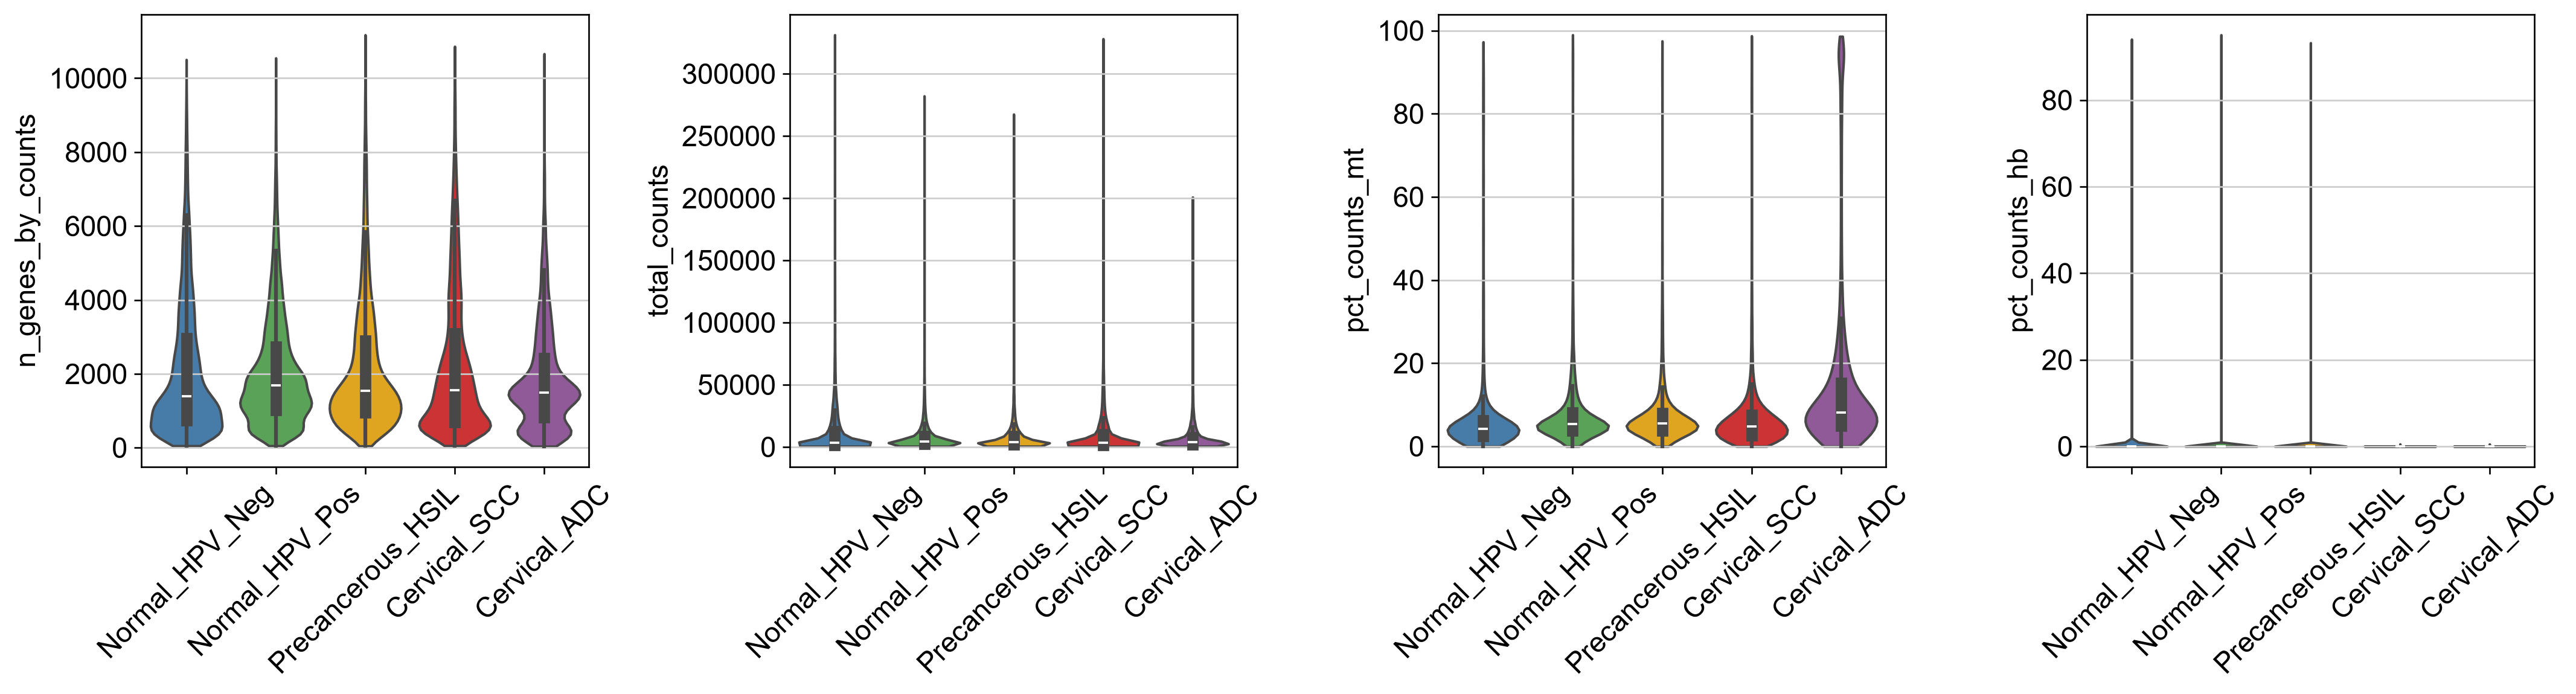

In [55]:
colors = {
    "Normal_HPV_Neg": "#377EB8",
    "Normal_HPV_Pos": "#4DAF4A",
    "Precancerous_HSIL": "#FFB000",
    "Cervical_SCC": "#E41A1C",
    "Cervical_ADC": "#984EA3"
}

genes = [
    "n_genes_by_counts",
    "total_counts",
    "pct_counts_mt",
    "pct_counts_hb"
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, gene in zip(axes, genes):

    sns.violinplot(
        data=adata.obs,
        x="group",
        y=gene,
        hue="group",
        palette=colors,
        legend=False,
        inner="box",
        cut=0,
        ax=ax
    )

    ax.set_xlabel("")
    ax.set_ylabel(gene)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.savefig(
    "results/figures/QC_violin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "results/figures/QC_violin.pdf",
    bbox_inches="tight"
)

plt.show()

In [56]:
# 4. Filter cells and genes
sc.pp.filter_cells(adata, min_genes=250)
sc.pp.filter_genes(adata, min_cells=5)
adata = adata[adata.obs["pct_counts_mt"] < 15.0, :].copy()
adata = adata[adata.obs["pct_counts_hb"] < 5.0, :].copy()
print(f"Cells remaining after QC: {adata.n_obs}")

filtered out 1747 cells that have less than 250 genes expressed
filtered out 2254 genes that are detected in less than 5 cells
Cells remaining after QC: 74722


In [57]:
adata.write("data/filtered/02_filter.h5ad")

**Normalization & Feature Selection**

In [75]:
adata.layers["counts"] = adata.X.copy()

# Total count normalization to 10,000 and log1p transformation
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata





normalizing counts per cell
    finished (0:00:02)


In [5]:
# Identify 2,500 highly variable genes
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2500
)

print("Number of HVGs:", adata.var["highly_variable"].sum())


NameError: name 'adata' is not defined

In [82]:
adata = adata[:, adata.var["highly_variable"]].copy()

print(adata.shape)


(74722, 2500)


In [78]:
adata.write("data/filtered/02_normalized_hvg_scaled.h5ad")

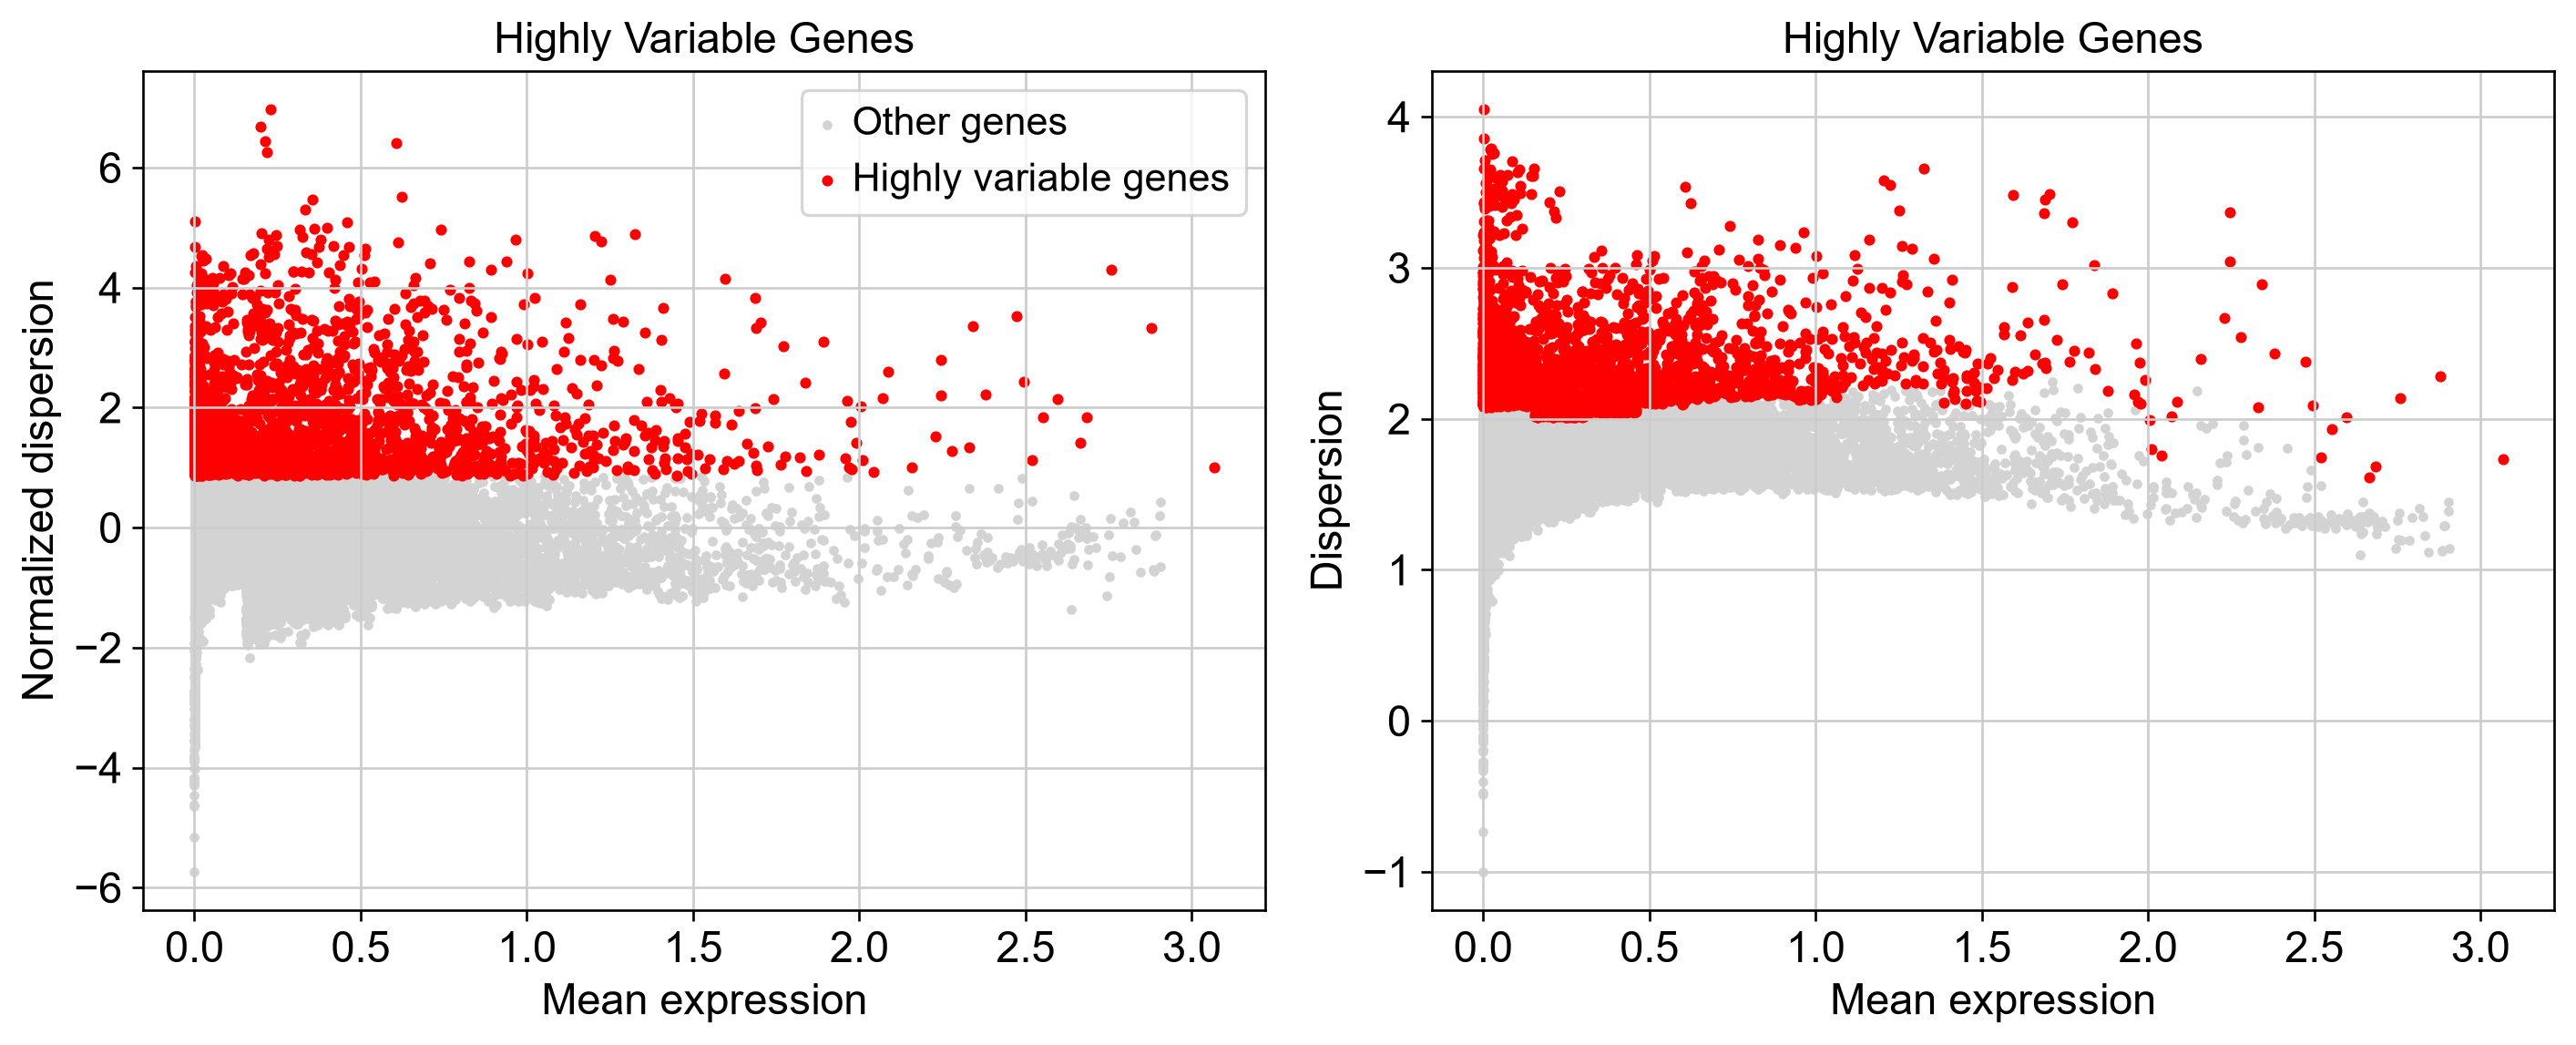

In [77]:
# Identify HVGs and other genes
hvg = adata.var["highly_variable"]

# Create figure with two panels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# Panel 1: Normalized dispersion
# -------------------------
axes[0].scatter(
    adata.var.loc[~hvg, "means"],
    adata.var.loc[~hvg, "dispersions_norm"],
    s=5,
    color="lightgrey",
    label="Other genes"
)

axes[0].scatter(
    adata.var.loc[hvg, "means"],
    adata.var.loc[hvg, "dispersions_norm"],
    s=7,
    color="red",
    label="Highly variable genes"
)

axes[0].set_xlabel("Mean expression")
axes[0].set_ylabel("Normalized dispersion")
axes[0].set_title("Highly Variable Genes")
axes[0].legend()


# -------------------------
# Panel 2: Dispersion
# -------------------------
axes[1].scatter(
    adata.var.loc[~hvg, "means"],
    adata.var.loc[~hvg, "dispersions"],
    s=5,
    color="lightgrey"
)

axes[1].scatter(
    adata.var.loc[hvg, "means"],
    adata.var.loc[hvg, "dispersions"],
    s=7,
    color="red"
)

axes[1].set_xlabel("Mean expression")
axes[1].set_ylabel("Dispersion")
axes[1].set_title("Highly Variable Genes")

plt.tight_layout()

# Save figure
plt.savefig(
    "results/figures/highly_variable_genes_colored.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "results/figures/highly_variable_genes_colored.pdf",
    bbox_inches="tight"
)

plt.show()

**Dimensionality Reduction & Graph-Based Clustering**

In [90]:
adata.raw = None
print(adata.raw)

None


In [11]:
print(adata.var["highly_variable"].sum())

2500


In [12]:
print("Shape:", adata.shape)
print("HVGs:", adata.var["highly_variable"].sum())
print("Backed:", adata.isbacked)

Shape: (74722, 18361)
HVGs: 2500
Backed: True


In [10]:
adata = sc.read_h5ad(
    "data/filtered/02_normalized_hvg_scaled.h5ad",
    backed="r"
)

print(adata.shape)

(74722, 18361)


computing PCA
    with n_comps=50
    finished (0:09:15)


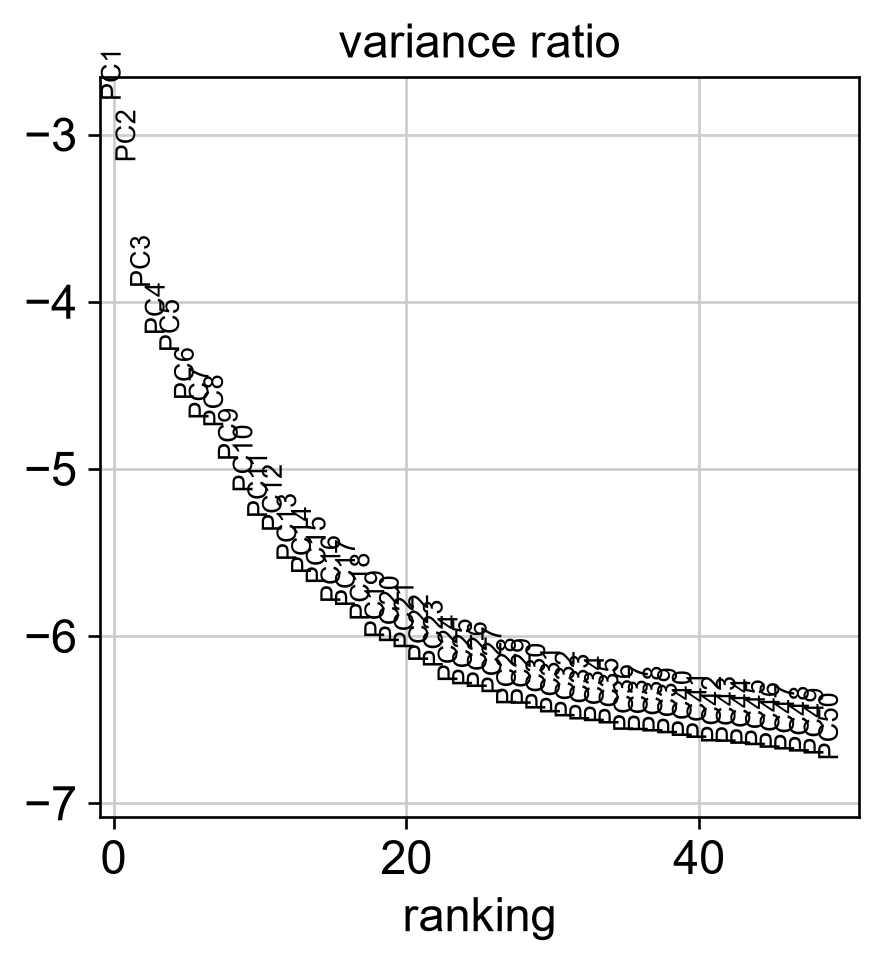

In [14]:
# PCA
sc.tl.pca(
    adata,
    n_comps=50,
    mask_var="highly_variable",
    chunked=True,
    chunk_size=2000
)

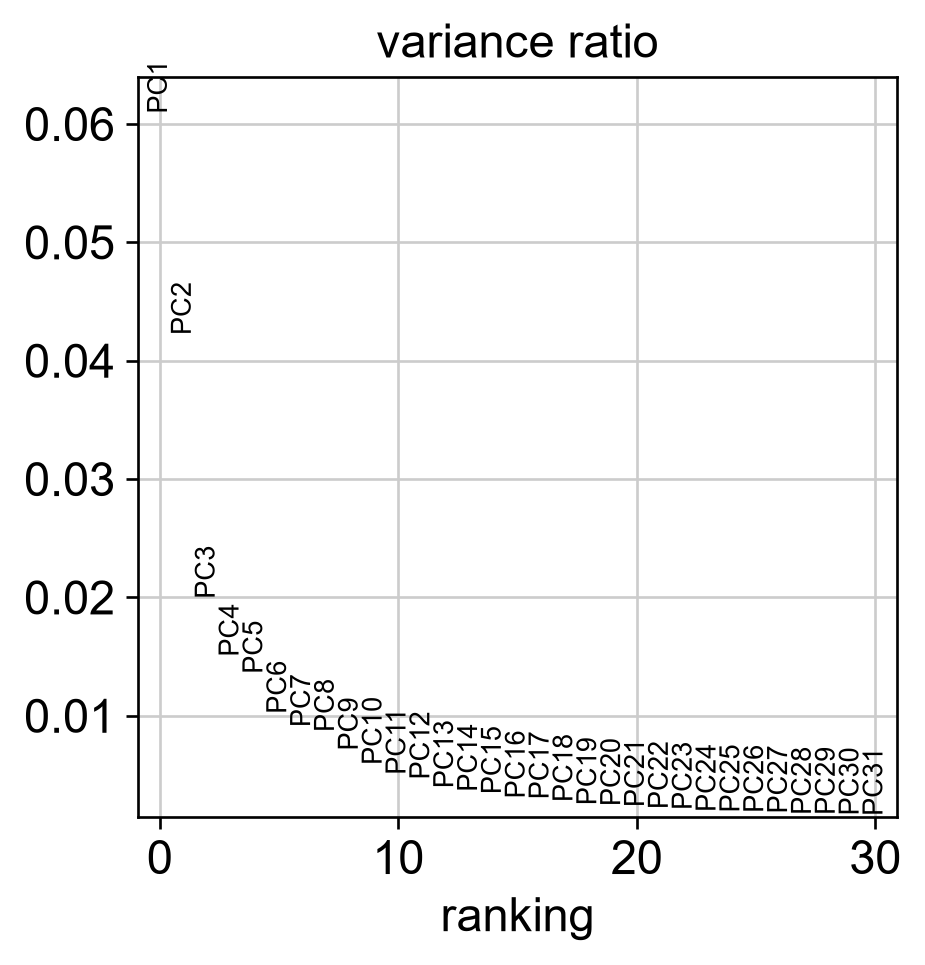

In [21]:
sc.pl.pca_variance_ratio(
    adata,
    log=False,
    n_pcs=30,
    show=False
)

plt.savefig(
    "results/figures/PCA_variance_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# Build neighbor graph & compute UMAP
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=30)
sc.tl.umap(adata)

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:04:35)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:24)


In [26]:
# Leiden clustering
sc.tl.leiden(
    adata,
    resolution=0.8,
    key_added="leiden_res_0.8",
    flavor="igraph",
    n_iterations=2,
    directed=False,
    random_state=0
)

running Leiden clustering
    finished: found 27 clusters and added
    'leiden_res_0.8', the cluster labels (adata.obs, categorical) (0:00:07)


In [33]:
Path("results/figures").mkdir(parents=True, exist_ok=True)
sc.settings.figdir = "results/figures"
sc.pl.umap(
    adata,
    color=["leiden_res_0.8", "group", "tissue_type", "sample"],
    ncols=2,
    show=False,
    save="_clustering.png"
)

[<Axes: title={'center': 'leiden_res_0.8'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'group'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'tissue_type'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'sample'}, xlabel='UMAP1', ylabel='UMAP2'>]

**Tumor Microenvironment Cell Type Annotation**

In [34]:
lineage_dict = { 
    "Epithelial_Tumor": 
                 ["EPCAM", "KRT5", "KRT14"], 
                 "T_cells": 
    ["CD3D", "CD4", "CD8A"], 
    "Tregs": 
    ["FOXP3", "IL2RA", "CTLA4"], 
    "NK": 
    ["NKG7", "NCAM1"], 
    "B_cells": 
    ["MS4A1", "CD79A"], 
    "Plasma": 
    ["SDC1", "MZB1"], 
    "Myeloid_TAM": 
    ["CD14", "CD68", "CD163"], 
    "Fibroblasts": 
    ["COL1A1", "ACTA2"], 
    "Endothelial": 
    ["PECAM1", "VWF"]}
sc.pl.dotplot(adata, 
              var_names=lineage_dict, 
              groupby="leiden_res_0.8",
             show=False,
    save="_marker_dotplot.png"
)
sc.pl.umap(adata, 
           color=["EPCAM", "CD3D", "CD68", "MS4A1", "COL1A1", "PECAM1"], 
           ncols=3,
           show=False,
    save="_marker_genes.png")

[<Axes: title={'center': 'EPCAM'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'CD3D'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'CD68'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'MS4A1'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'COL1A1'}, xlabel='UMAP1', ylabel='UMAP2'>,
 <Axes: title={'center': 'PECAM1'}, xlabel='UMAP1', ylabel='UMAP2'>]

**Evaluating T-Cell Exhaustion & Immune Checkpoint Expression**

In [36]:
exhaustion_genes = ["PDCD1", "CTLA4", "HAVCR2", "LAG3", "TIGIT", "FOXP3"]
available_exhaustion = [g 
                        for g in exhaustion_genes 
                        if g in adata.var_names]
sc.pl.violin( adata, keys=available_exhaustion, 
              groupby="group", 
              rotation=45, 
              multi_panel=True,
            show = False,
            save= "_exhaustion_gene.png")

[<Axes: ylabel='PDCD1'>,
 <Axes: ylabel='CTLA4'>,
 <Axes: ylabel='HAVCR2'>,
 <Axes: ylabel='LAG3'>,
 <Axes: ylabel='TIGIT'>,
 <Axes: ylabel='FOXP3'>]

In [39]:
print(adata.obs["group"].value_counts())

group
Normal_HPV_Pos       21151
Normal_HPV_Neg       18953
Cervical_SCC         14586
Precancerous_HSIL    12484
Cervical_ADC          7548
Name: count, dtype: int64


In [48]:
adata_stage = adata[
    adata.obs["group"].isin([
        "Normal_HPV_Neg",
        "Normal_HPV_Pos",
        "Precancerous_HSIL",
        "Cervical_SCC",
        "Cervical_ADC"
    ])
].to_memory()

print(adata_stage.shape)

(74722, 18361)


In [49]:
adata_stage.obs["stage"] = adata_stage.obs["group"].map({
    "Normal_HPV_Neg": "Normal",
    "Normal_HPV_Pos": "Normal",
    "Precancerous_HSIL": "HSIL",
    "Cervical_SCC": "SCC",
    "Cervical_ADC": "ADC"
})

adata_stage.obs["stage"] = adata_stage.obs["stage"].astype("category")

print(adata_stage.obs["stage"].value_counts())

stage
Normal    40104
SCC       14586
HSIL      12484
ADC        7548
Name: count, dtype: int64


In [50]:
print(adata_stage.shape)
print(adata_stage.isbacked)

(74722, 18361)
False


In [51]:
sc.tl.rank_genes_groups(
    adata_stage,
    groupby="stage",
    method="wilcoxon",
    pts=True
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:02:55)


In [52]:
de_normal = sc.get.rank_genes_groups_df(adata_stage, group="Normal")
de_hsil   = sc.get.rank_genes_groups_df(adata_stage, group="HSIL")
de_scc    = sc.get.rank_genes_groups_df(adata_stage, group="SCC")
de_adc    = sc.get.rank_genes_groups_df(adata_stage, group="ADC")

In [53]:
Path("results/tables").mkdir(parents=True, exist_ok=True)

de_normal.to_csv("results/tables/DE_Normal.csv", index=False)
de_hsil.to_csv("results/tables/DE_HSIL.csv", index=False)
de_scc.to_csv("results/tables/DE_SCC.csv", index=False)
de_adc.to_csv("results/tables/DE_ADC.csv", index=False)

In [43]:
# Differential expression between Tumor (SCC) and Normal tissue
sc.tl.rank_genes_groups(
    scc_normal,
    groupby="group",
    groups=["Cervical_SCC"],
    reference="Normal_HPV_Neg",
    method="wilcoxon",
    pts=True
)
scc_de_df = sc.get.rank_genes_groups_df(
    scc_normal,
    group="Cervical_SCC"
)

print(scc_de_df.head(20))

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:03:09)
       names     scores  logfoldchanges  pvals  pvals_adj  pct_nz_group
0   C15orf48  53.477520        2.321470    0.0        0.0      0.495681
1    TNFAIP3  53.269897        1.702663    0.0        0.0      0.634033
2      STAT1  52.725670        1.825155    0.0        0.0      0.560675
3       IFI6  51.693142        1.841622    0.0        0.0      0.531400
4       GBP1  51.148804        2.472232    0.0        0.0      0.452831
5       GBP5  47.847691        2.559174    0.0        0.0      0.407034
6     RNF213  46.925980        1.088363    0.0        0.0      0.768340
7      ISG15  46.419380        1.397855 

In [44]:
Path("results/tables").mkdir(parents=True, exist_ok=True)

scc_de_df.to_csv(
    "results/tables/SCC_vs_Normal_DE_genes.csv",
    index=False
)

**Pathway Enrichment Analysis with GSEApy**

In [8]:
import os
print(os.getcwd())

D:\bmp\scRNAseq\sc-project-data\project4_immune_remodeling_cc


In [7]:
os.chdir("D:/bmp/scRNAseq/sc-project-data/project4_immune_remodeling_cc")

In [9]:


adata = sc.read_h5ad(
    "data/filtered/02_normalized_hvg_scaled.h5ad",
    backed="r"
)

print(adata.shape)

(74722, 18361)


In [10]:
adata_stage = adata[
    adata.obs["group"].isin([
        "Normal_HPV_Neg",
        "Normal_HPV_Pos",
        "Precancerous_HSIL",
        "Cervical_SCC",
        "Cervical_ADC"
    ])
]

print(adata_stage.shape)

(74722, 18361)


In [13]:
adata.obs["stage"] = adata.obs["group"].map({
    "Normal_HPV_Neg": "Normal",
    "Normal_HPV_Pos": "Normal",
    "Precancerous_HSIL": "HSIL",
    "Cervical_SCC": "SCC",
    "Cervical_ADC": "ADC"
})

adata.obs["stage"] = adata.obs["stage"].astype("category")

print(adata.obs["stage"].value_counts())

stage
Normal    40104
SCC       14586
HSIL      12484
ADC        7548
Name: count, dtype: int64


In [17]:
adata_stage = adata[
    adata.obs["group"].isin([
        "Normal_HPV_Neg",
        "Normal_HPV_Pos",
        "Precancerous_HSIL",
        "Cervical_SCC",
        "Cervical_ADC"
    ])
].copy(
    filename="data/filtered/adata_stage.h5ad"
)

In [18]:
import scanpy as sc

adata_stage = sc.read_h5ad(
    "data/filtered/adata_stage.h5ad"
)

print(adata_stage.shape)
print(adata_stage.isbacked)

(74722, 18361)
False


In [20]:
adata_stage.raw = None

In [25]:

import os

for root, dirs, files in os.walk("D:/bmp/scRNAseq/sc-project-data/project4_immune_remodeling_cc"):
    for file in files:
        if "DE_" in file:
            print(os.path.join(root, file))

D:/bmp/scRNAseq/sc-project-data/project4_immune_remodeling_cc\data\filtered\DE_HVG_2500.h5ad
D:/bmp/scRNAseq/sc-project-data/project4_immune_remodeling_cc\results\tables\DE_ADC.csv
D:/bmp/scRNAseq/sc-project-data/project4_immune_remodeling_cc\results\tables\DE_HSIL.csv
D:/bmp/scRNAseq/sc-project-data/project4_immune_remodeling_cc\results\tables\DE_Normal.csv
D:/bmp/scRNAseq/sc-project-data/project4_immune_remodeling_cc\results\tables\DE_SCC.csv


In [30]:
de_files = {
    "SCC": r"D:\bmp\scRNAseq\sc-project-data\project4_immune_remodeling_cc\results\tables\DE_SCC.csv",
    "ADC": r"D:\bmp\scRNAseq\sc-project-data\project4_immune_remodeling_cc\results\tables\DE_ADC.csv",
    "HSIL": r"D:\bmp\scRNAseq\sc-project-data\project4_immune_remodeling_cc\results\tables\DE_HSIL.csv",
    "Normal": r"D:\bmp\scRNAseq\sc-project-data\project4_immune_remodeling_cc\results\tables\DE_Normal.csv"
}

In [31]:
de_results = {}

for group, file in de_files.items():
    de_results[group] = pd.read_csv(file)
    print(group, de_results[group].shape)

SCC (18361, 7)
ADC (18361, 7)
HSIL (18361, 7)
Normal (18361, 7)


In [32]:
print(de_results["SCC"].columns.tolist())

['names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj', 'pct_nz_group', 'pct_nz_reference']


In [33]:
import gseapy as gp

Path("results/enrichment").mkdir(parents=True, exist_ok=True)

for group, de_df in de_results.items():

    print(f"\nRunning ORA for {group}")

    sig_genes = de_df[
        (de_df["logfoldchanges"] > 1.0) &
        (de_df["pvals_adj"] < 0.01)
    ]["names"].dropna().tolist()

    print("Significant upregulated genes:", len(sig_genes))

    if len(sig_genes) == 0:
        print("No significant genes. Skipping.")
        continue

    enr = gp.enrichr(
        gene_list=sig_genes,
        gene_sets=[
            "KEGG_2021_Human",
            "GO_Biological_Process_2023",
            "Reactome_2022"
        ],
        organism="human",
        outdir=None
    )

    enr.results.to_csv(
        f"results/enrichment/ORA_{group}.csv",
        index=False
    )

    print(
        enr.results.head(10)[
            ["Gene_set", "Term", "Adjusted P-value"]
        ]
    )


Running ORA for SCC
Significant upregulated genes: 665
          Gene_set                                               Term  \
0  KEGG_2021_Human                                       Tuberculosis   
1  KEGG_2021_Human                    Staphylococcus aureus infection   
2  KEGG_2021_Human                                          Phagosome   
3  KEGG_2021_Human                               Rheumatoid arthritis   
4  KEGG_2021_Human                                      Leishmaniasis   
5  KEGG_2021_Human  Viral protein interaction with cytokine and cy...   
6  KEGG_2021_Human                         Osteoclast differentiation   
7  KEGG_2021_Human                Antigen processing and presentation   
8  KEGG_2021_Human                       Epstein-Barr virus infection   
9  KEGG_2021_Human                                        Influenza A   

   Adjusted P-value  
0      4.624913e-10  
1      4.526098e-09  
2      1.971035e-08  
3      9.264245e-08  
4      1.364314e-06  
5      1

In [35]:
ora_results = {}

for group in ["SCC", "ADC", "HSIL", "Normal"]:
    
    ora_results[group] = pd.read_csv(
        f"results/enrichment/ORA_{group}.csv"
    )
    
    print(
        group,
        ora_results[group].shape
    )
    

SCC (4168, 10)
ADC (620, 10)
HSIL (4296, 10)
Normal (3334, 10)


In [39]:
combined = []

for group, df in ora_results.items():

    temp = df.copy()

    temp["Group"] = group

    # Select top 10 pathways by adjusted p-value
    temp = temp.sort_values(
        "Adjusted P-value"
    ).head(10)

    combined.append(temp)


combined = pd.concat(combined)

print(combined.head())


                        Gene_set  \
3153               Reactome_2022   
266   GO_Biological_Process_2023   
3154               Reactome_2022   
267   GO_Biological_Process_2023   
268   GO_Biological_Process_2023   

                                                   Term   Overlap  \
3153                         Immune System R-HSA-168256  157/1943   
266                  Inflammatory Response (GO:0006954)    46/236   
3154  Cytokine Signaling In Immune System R-HSA-1280215    73/702   
267    Cytokine-Mediated Signaling Pathway (GO:0019221)    40/257   
268   Negative Regulation Of T Cell Proliferation (G...     16/36   

           P-value  Adjusted P-value  Old P-value  Old Adjusted P-value  \
3153  9.160931e-27      9.298345e-24            0                     0   
266   1.422725e-22      4.107408e-19            0                     0   
3154  3.755539e-18      1.905936e-15            0                     0   
267   3.389060e-16      4.892108e-13            0                   

In [41]:
Path("results/enrichment").mkdir(
    parents=True,
    exist_ok=True
)

combined.to_csv(
    "results/enrichment/ORA_all_groups_combined.csv",
    index=False
)

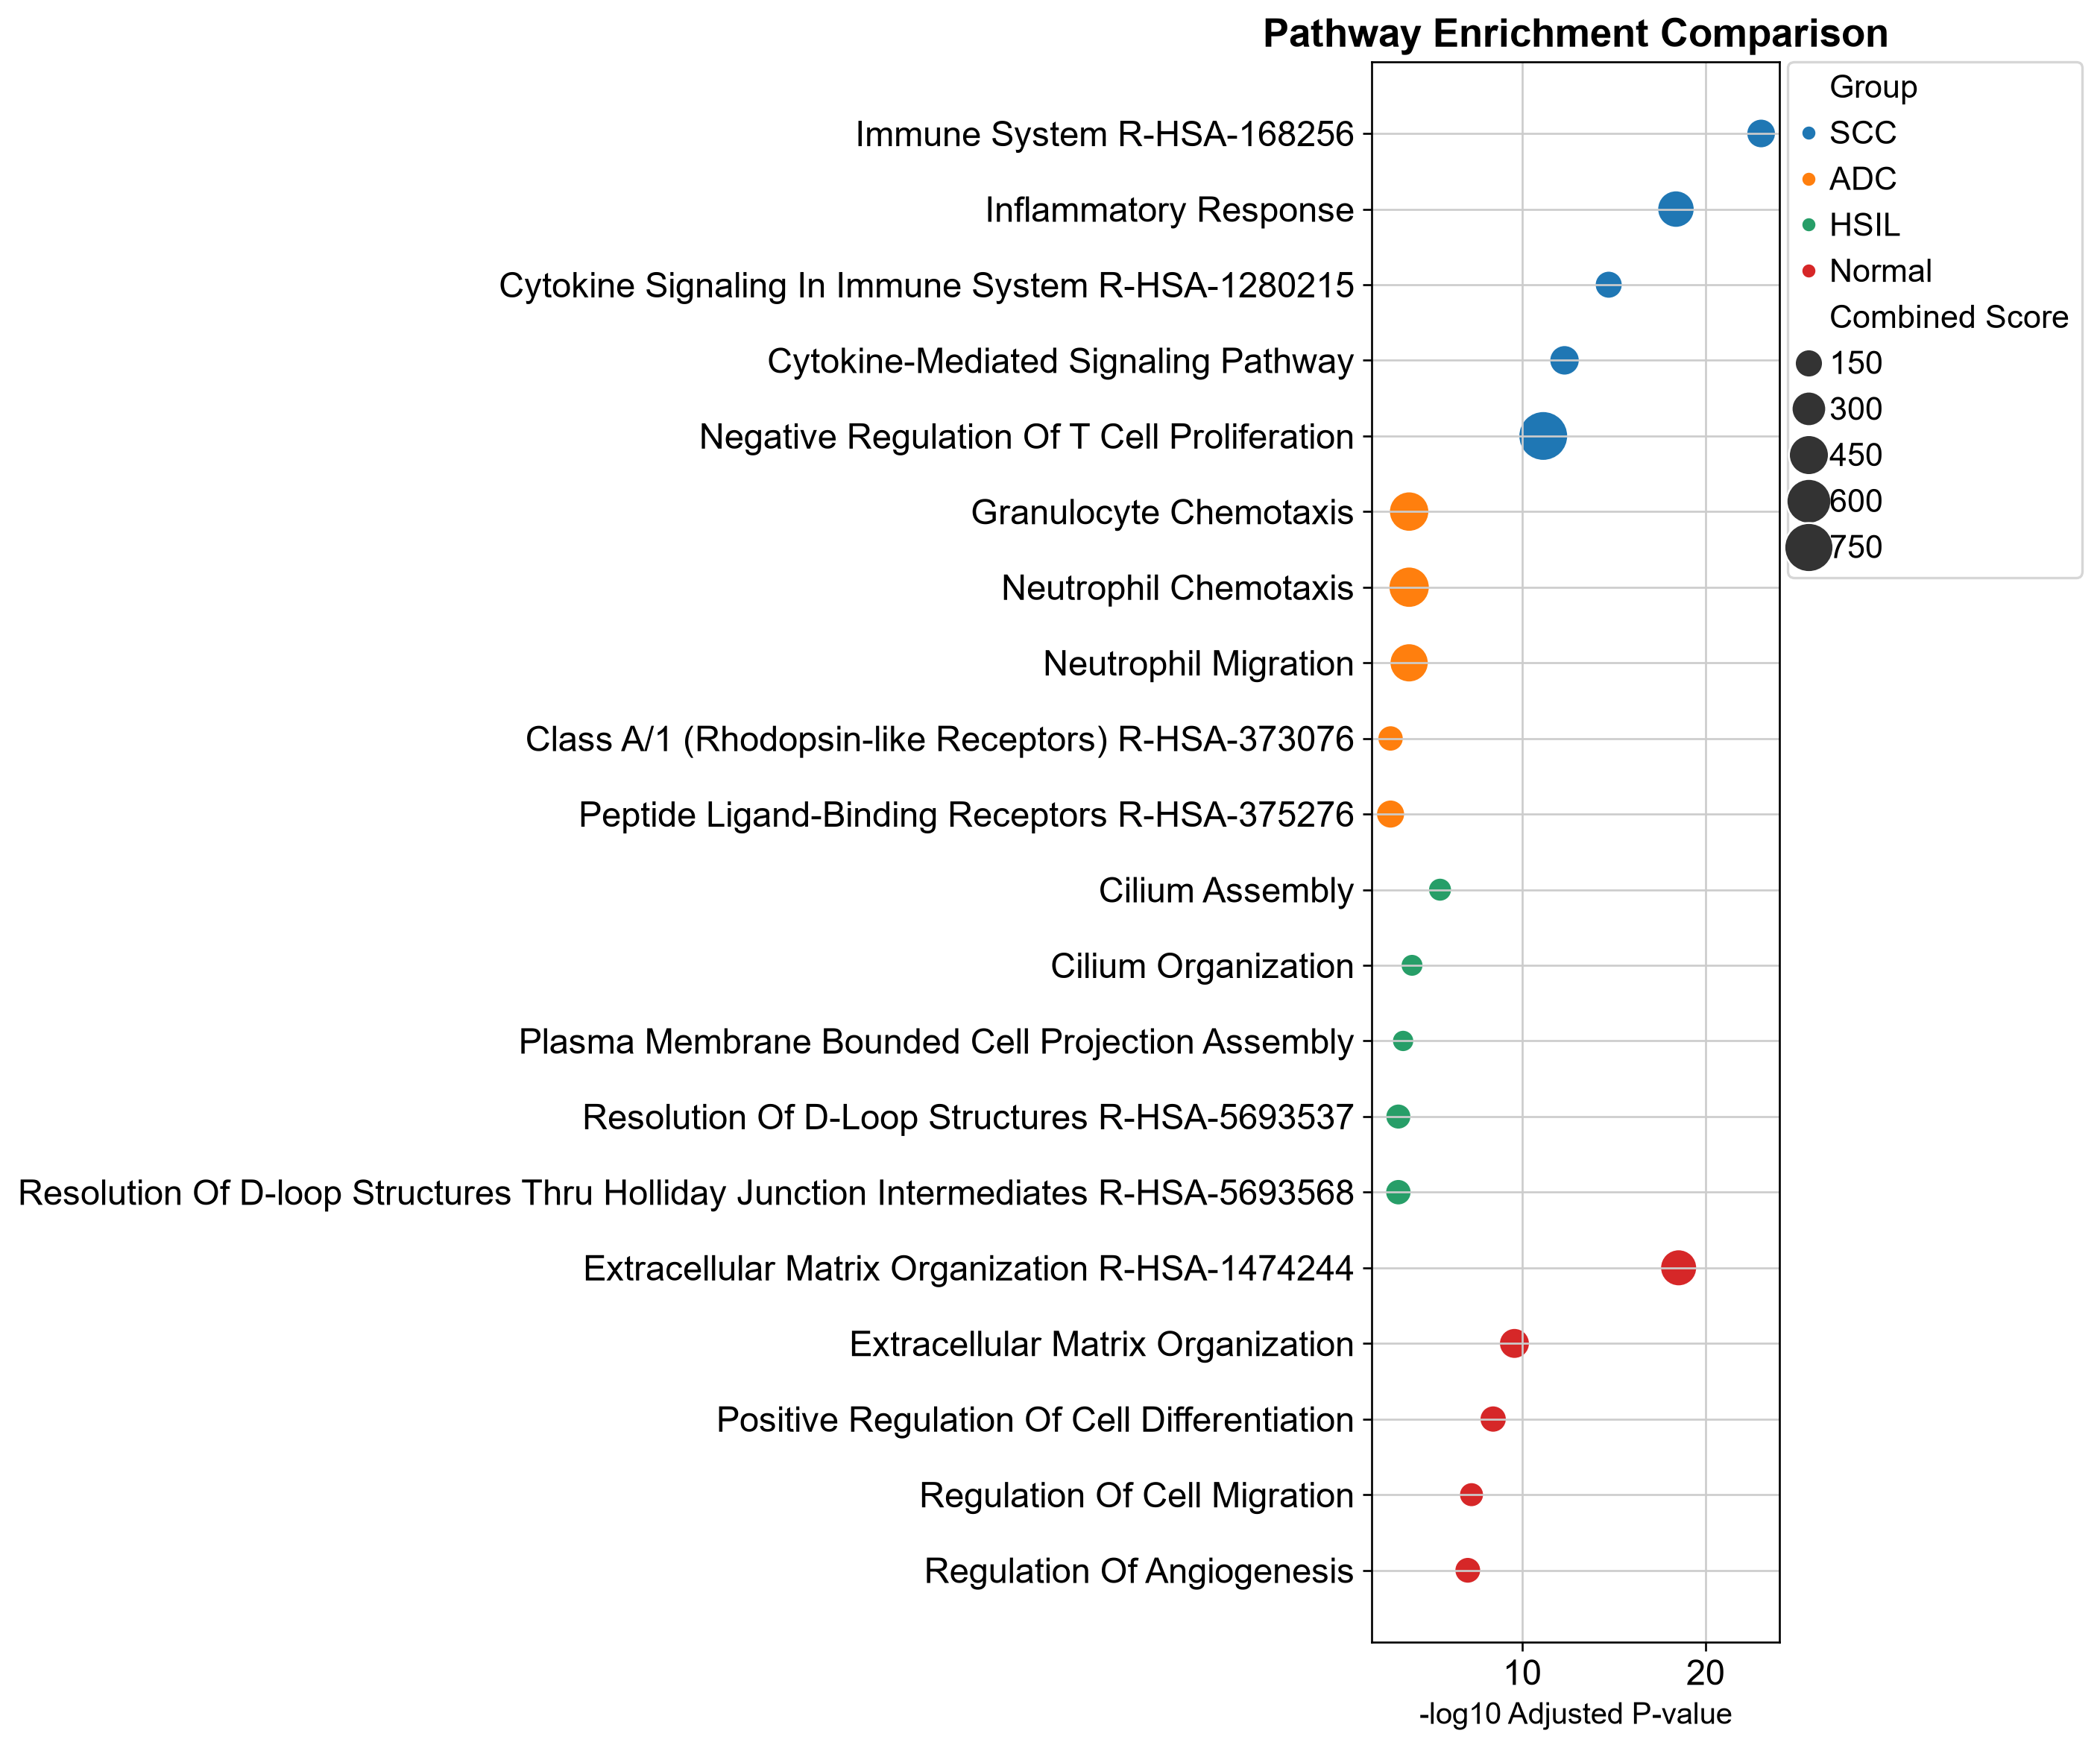

In [43]:




Path("results/figures").mkdir(
    parents=True,
    exist_ok=True
)

# Select top pathways
plot_df = []

for group, df in ora_results.items():

    temp = df.copy()

    # remove duplicated pathways
    temp = temp.drop_duplicates("Term")

    # select top 5 significant pathways
    temp = temp.sort_values(
        "Adjusted P-value"
    ).head(5)

    temp["Group"] = group

    plot_df.append(temp)


plot_df = pd.concat(plot_df)


# Shorten pathway names
plot_df["Pathway"] = (
    plot_df["Term"]
    .str.replace(
        r"\s*\(GO:\d+\)",
        "",
        regex=True
    )
    .str.replace(
        "Reactome_2022: ",
        "",
        regex=False
    )
    .str.replace(
        "GO_Biological_Process_2023: ",
        "",
        regex=False
    )
)


# Calculate significance
plot_df["-log10(adj P)"] = (
    -np.log10(plot_df["Adjusted P-value"])
)


# Plot

plt.figure(figsize=(12,10))


sns.scatterplot(
    data=plot_df,
    x="-log10(adj P)",
    y="Pathway",
    hue="Group",
    size="Combined Score",
    sizes=(80,400)
)


plt.xlabel(
    "-log10 Adjusted P-value",
    fontsize=12
)

plt.ylabel(
    "",
    fontsize=12
)

plt.title(
    "Pathway Enrichment Comparison",
    fontsize=16,
    weight="bold"
)


# Move legend outside
plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    borderaxespad=0
)


plt.tight_layout()


plt.savefig(
    "results/figures/ORA_pathway_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()